In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter
from pathlib import Path

def plot(
    df, metric, methods, display_names=None, ylabel=None, title=None,
    backend=None, idx=None, figsize=(8.5, 5.5), use_log_scale=False
):
    """
    Publication-style plot of a given metric vs. cycle for multiple methods.
    Shows only mean ± std (no scatter points).
    - Matches the QROQI publication plotting style.
    - Saves as PDF in figures/static/{backend}/{idx}qpt/{metric}.pdf
    """
    if display_names is None:
        display_names = {m: m for m in methods}
    if ylabel is None:
        ylabel = metric.capitalize()
    if title is None:
        title = metric

    # ---- Publication style ----
    plt.rcParams.update({
        "font.size": 20,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "legend.title_fontsize": 20,
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "figure.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    # ---- Group data by cycle ----
    data_grouped = {m: defaultdict(list) for m in methods}
    for _, row in df.iterrows():
        x = row['cycle']
        for m in methods:
            col = f"{m}_{metric}"
            if col in df.columns and not pd.isnull(row[col]):
                data_grouped[m][x].append(row[col])

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=figsize)
    colors = list(plt.cm.tab10.colors)
    # i want the first will be orange (second on list of tab10) and the fifth to be blue (first on list of tab10)
    colors = [colors[1],  colors[2], colors[3], colors[4], colors[5], colors[0]]
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X']

    for i, m in enumerate(methods):
        label = display_names.get(m, m)
        grouped = data_grouped[m]
        xs = sorted(grouped.keys())
        ys_lists = [grouped[x] for x in xs]

        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]

        means = np.array([np.mean(y) for y in ys_lists])
        stds  = np.array([np.std(y)  for y in ys_lists])

        # Plot mean points + connecting line
        ax.plot(xs, means, color=color, marker=marker, label=label)
        # Add std shading
        ax.fill_between(xs, means - stds, means + stds, color=color, alpha=0.15)

    # ---- Axis formatting ----
    def thousands_formatter(x, pos):
        return f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    ax.set_xlabel("Initial depth")
    ax.set_ylabel(ylabel)
    if use_log_scale:
        ax.set_yscale("log")

    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", frameon=False)
    ax.set_ylim(bottom=0)

    plt.tight_layout()

    # ---- Save PDF ----
    if backend and idx is not None:
        save_dir = Path(f"figures/static/ablation/{backend}/{idx}qpt")
        save_dir.mkdir(parents=True, exist_ok=True)
        filename_map = {"avg_error": "error", "max_time": "latency"}
        filename = filename_map.get(metric, metric)
        save_path = save_dir / f"{filename}.pdf"
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"📄 Saved PDF: {save_path}")

    # plt.show()
    plt.close(fig)


In [61]:
# import pandas as pd
# import numpy as np
# import os

# backend = "ibm_brisbane"
# sizes = ["qasmbench-medium", "qasmbench-large"]

# methods = ['sabre', 'cirq', 'qmap', 'pytket', 'qlosure', 'qroqi']
# metrics = ['depth', 'latency', 'error', 'swaps']

# def load_results(idx):
#     df = None
#     for method in methods:
#         file_path = f'results/{backend}/{idx}/{method}.csv'
#         if not os.path.exists(file_path):
#             print(f"⚠️ {file_path} not found")
#             continue

#         temp_df = pd.read_csv(file_path)
#         # Add prefix so metrics can be merged
#         temp_df = temp_df.add_prefix(f"{method}_")
#         temp_df.rename(columns={f"{method}_filename": "filename"}, inplace=True)

#         if df is None:
#             df = temp_df
#         else:
#             df = pd.merge(df, temp_df, on="filename", how="outer")

#     return df


# def find_best_instance(df):
#     """Find filename where QRoQI dominates all others on all metrics."""
#     results = []
#     for _, row in df.iterrows():
#         improved_all = True
#         improvements = []
#         for m in metrics:
#             qroq = row.get(f'with_depth_{m}', np.nan)
#             if pd.isna(qroq):
#                 improved_all = False
#                 break

#             # Check if QRoQI strictly better (lower) than all others
#             better = True
#             rel_impr_values = []
#             for meth in methods:
#                 if meth == 'with_depth':
#                     continue
#                 val = row.get(f'{meth}_{m}', np.nan)
#                 if pd.isna(val):
#                     continue
#                 if qroq >= val:  # not better
#                     better = False
#                     break
#                 rel_impr_values.append((val - qroq) / val * 100)
#             if not better:
#                 improved_all = False
#                 break
#             if rel_impr_values:
#                 improvements.append(np.mean(rel_impr_values))

#         if improved_all and improvements:
#             avg_impr = np.mean(improvements)
#             results.append((row['filename'], avg_impr))

#     if results:
#         results.sort(key=lambda x: x[1], reverse=True)
#         return results[0], results[:5]  # top and top5
#     return None, []


# best_overall = []
# for idx in sizes:
#     print(f"\n🔍 Analyzing {backend} — {idx} ...")
#     df = load_results(idx)
#     if df is not None:
#         best_instance, top5 = find_best_instance(df)
#         if best_instance:
#             filename, score = best_instance
#             print(f"✅ Best instance for {idx}: {filename} (avg_impr={score:.2f}%)")
#             best_overall.append((idx, filename, score))

#             # show top 5 improvements for this set
#             print("Top 5 improved circuits:")
#             for f, s in top5:
#                 print(f"  • {f:40s}  {s:6.2f}%")
#         else:
#             print("No instance found where QRoQI improves all metrics.")

# if best_overall:
#     best_overall.sort(key=lambda x: x[2], reverse=True)
#     idx, filename, score = best_overall[0]
#     print(f"\n🏆 Motivation figure candidate → {idx} / {filename} on {backend}")
#     print(f"   QRoQI improves all metrics vs all baselines, avg improvement: {score:.2f}%")
# else:
#     print("No perfect all-metric improvement found.")


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- Parameters ---
backend = "brisbane"
idx = 121
cycle, run = 600.0, 3.0

methods = ['sabre', 'cirq', 'qmap', 'pytket', 'original_qlosure', 'with_depth']
display_names = {
    'sabre': 'Sabre',
    'qmap': 'Qmap',
    'cirq': 'Cirq',
    'pytket': 'Pytket',
    'original_qlosure': 'Qlosure',
    'with_depth': 'Us',
}
metrics = ['swaps', 'depth', 'max_time', 'avg_error']
metric_names = ['S', 'D', 'L', 'E']

# --- Load and merge data ---
merge_cols = ['cycle', 'run']
df = None
for method in methods:
    file_path = f'results/{backend}/{idx}qpt/{method}.csv'
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} not found, skipping.")
        continue

    temp_df = pd.read_csv(file_path)
    temp_df = temp_df[(temp_df['cycle'] == cycle) & (temp_df['run'] == run)]
    temp_df.rename(columns={f"{method}_cycle": "cycle", f"{method}_run": "run"}, inplace=True)
    if not temp_df.empty:
        df = temp_df if df is None else pd.merge(df, temp_df, on=["cycle", "run"], how="outer")

if df is None or df.empty:
    raise ValueError("No data found for the given parameters.")

# --- Extract values ---
values = {m: [df[f'{method}_{m}'].values[0] for method in methods] for m in metrics}

# --- Normalize (optional) ---
normalize = True
if normalize:
    for m in metrics:
        baseline = np.max(values[m])
        values[m] = [v / baseline if baseline > 0 else v for v in values[m]]

# --- Plot ---
x = np.arange(len(metrics))
width = 0.13

colors = list(plt.cm.tab10.colors)
colors = [colors[1], colors[2], colors[3], colors[4], colors[5], colors[0]]

# 🌟 Best visually distinct hatches for papers
# Includes stars, dots, dense crosses, and slashes
hatches = ['*', 'o', 'x', 'O', '//', '\\\\']

plt.figure(figsize=(8, 4.5))
for i, method in enumerate(methods):
    bars = plt.bar(
        x + i * width - (width * len(methods) / 2),
        [values[m][i] for m in metrics],
        width=width,
        label=display_names[method],
        color=colors[i],
        edgecolor='black',
        hatch=hatches[i % len(hatches)],
        linewidth=0.6
    )

plt.xticks(x, metric_names, fontsize=22)
plt.ylabel('Normalized Metric Value', fontsize=19)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --- Legend: single row with spacing ---
handles, labels = plt.gca().get_legend_handles_labels()

show_labels = ['Pytket', 'Qlosure', 'Us']
selected = [(h, l) for h, l in zip(handles, labels) if l in show_labels]
sel_handles, sel_labels = zip(*selected)

plt.legend(
    sel_handles, sel_labels,
    frameon=True,
    fontsize=26,
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.27),
    fancybox=True,
    shadow=False,
    framealpha=1,
    borderpad=0.6,
    columnspacing=1.3,
    handlelength=1.8
)

plt.tight_layout()
plt.subplots_adjust(top=0.8)

# --- Save as high-quality PDF ---
output_path = f'ibm_brisbane_121QBT_600CYC_QSE_3.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Figure saved as {output_path}")

improvements = {}
for m in metrics:
    qroq = df[f'with_depth_{m}'].values[0]
    if pd.isna(qroq):
        continue

    rel_impr_values = []
    for meth in methods:
        if meth == 'qroqi':
            continue
        val = df[f'{meth}_{m}'].values[0]
        if pd.isna(val):
            continue
        if qroq < val:  # only consider improvements
            rel_impr = (val - qroq) / val * 100
            rel_impr_values.append(rel_impr)
            
            print(f"  • {meth} on {m}: improvement: {rel_impr:.2f}%")


⚠️ results/brisbane/121qpt/sabre.csv not found, skipping.
⚠️ results/brisbane/121qpt/cirq.csv not found, skipping.
⚠️ results/brisbane/121qpt/qmap.csv not found, skipping.
⚠️ results/brisbane/121qpt/pytket.csv not found, skipping.
⚠️ results/brisbane/121qpt/original_qlosure.csv not found, skipping.
⚠️ results/brisbane/121qpt/with_depth.csv not found, skipping.


ValueError: No data found for the given parameters.

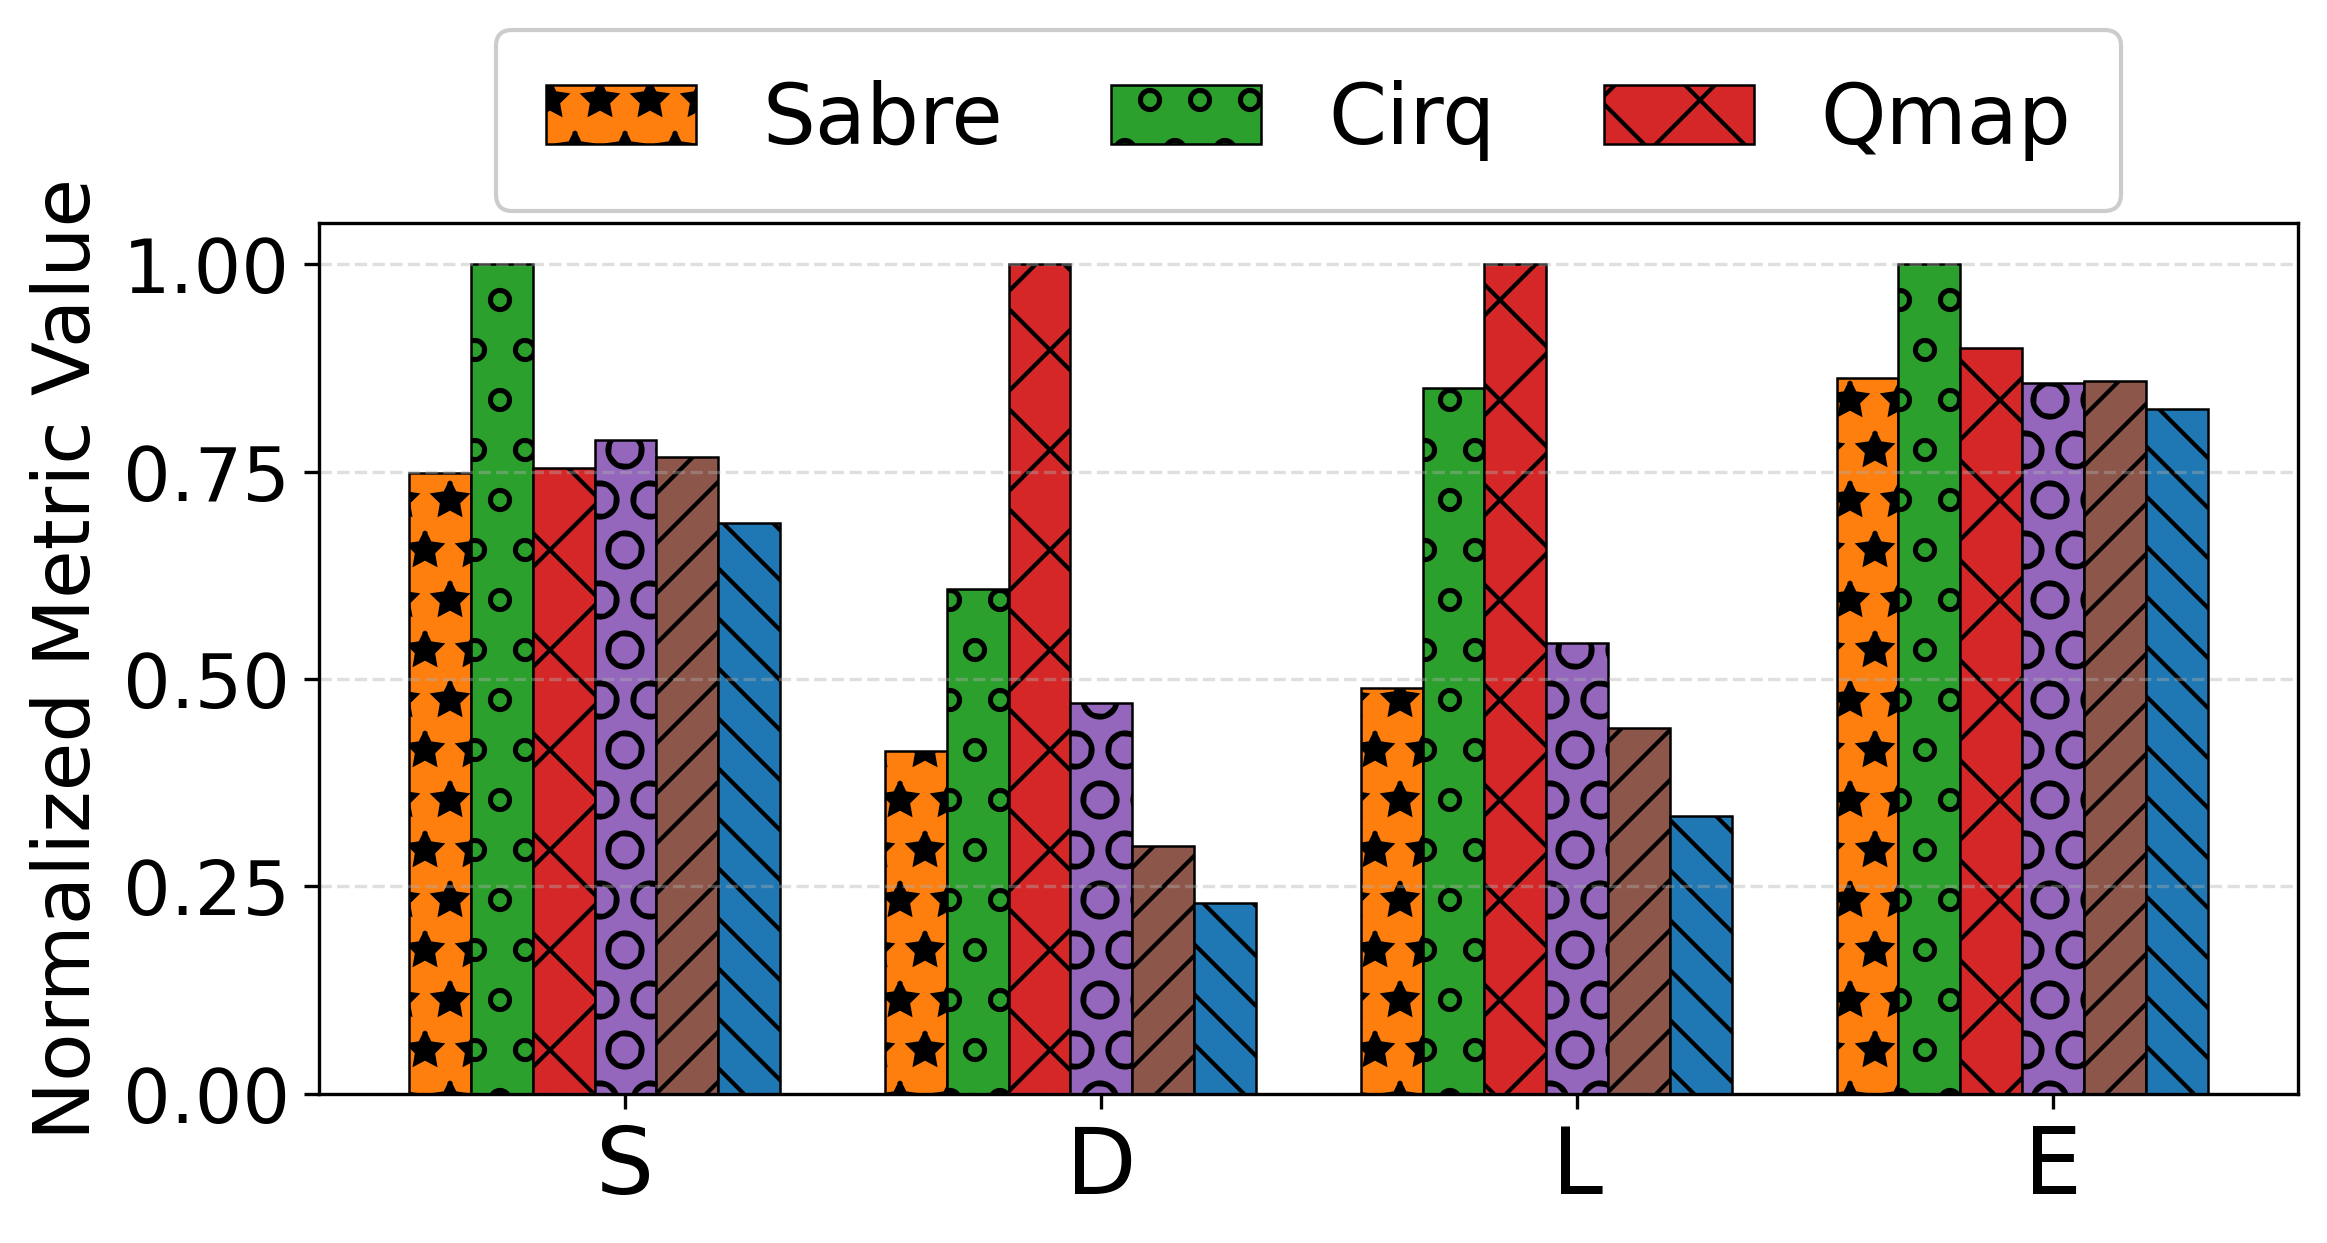

✅ Figure saved as ibm_brisbane_qasmbench-large_ising_n66__16CYC.pdf
  • sabre on swaps: improvement: 7.96%
  • cirq on swaps: improvement: 31.13%
  • qmap on swaps: improvement: 8.77%
  • pytket on swaps: improvement: 12.61%
  • qlosure on swaps: improvement: 10.34%
  • sabre on depth: improvement: 44.44%
  • cirq on depth: improvement: 62.26%
  • qmap on depth: improvement: 77.01%
  • pytket on depth: improvement: 51.22%
  • qlosure on depth: improvement: 23.08%
  • sabre on latency: improvement: 31.37%
  • cirq on latency: improvement: 60.60%
  • qmap on latency: improvement: 66.45%
  • pytket on latency: improvement: 38.24%
  • qlosure on latency: improvement: 23.91%
  • sabre on error: improvement: 4.33%
  • cirq on error: improvement: 17.45%
  • qmap on error: improvement: 8.18%
  • pytket on error: improvement: 3.75%
  • qlosure on error: improvement: 3.95%


In [88]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- Parameters ---
backend = "ibm_brisbane"
dataset = "qasmbench-large"   # or "queko-bss-121qbt"
filename = "ising_n66__16CYC.json"
normalize = True  # set to False for raw values

methods = ['sabre', 'cirq', 'qmap', 'pytket', 'qlosure', 'qroqi']
display_names = {
    'sabre': 'Sabre',
    'qmap': 'Qmap',
    'cirq': 'Cirq',
    'pytket': 'Pytket',
    'qlosure': 'Qlosure',
    'qroqi': 'Us',
}

metrics = ['swaps', 'depth', 'latency', 'error']
metric_names = ['S', 'D', 'L', 'E']

# --- Load and merge data for this circuit ---
df = None
for method in methods:
    file_path = f'results/{backend}/{dataset}/{method}.csv'
    if not os.path.exists(file_path):
        print(f"⚠️ {file_path} not found.")
        continue

    temp_df = pd.read_csv(file_path)
    temp_df = temp_df[temp_df['filename'] == filename]
    if temp_df.empty:
        continue

    temp_df = temp_df.add_prefix(f"{method}_")
    temp_df.rename(columns={f"{method}_filename": "filename"}, inplace=True)
    df = temp_df if df is None else pd.merge(df, temp_df, on=["filename"], how="outer")

if df is None or df.empty:
    raise ValueError(f"No data found for {filename} in {dataset}")

# --- Extract metric values ---
values = {m: [df[f'{method}_{m}'].values[0] for method in methods] for m in metrics}

# --- Normalize (optional) ---
if normalize:
    for m in metrics:
        baseline = np.max(values[m])  # normalize to the worst value
        values[m] = [v / baseline if baseline > 0 else v for v in values[m]]
    ylabel = "Normalized Metric Value"
else:
    ylabel = "Metric Value (↓ better)"

# --- Plot setup ---
x = np.arange(len(metrics))
width = 0.13

colors = list(plt.cm.tab10.colors)
colors = [colors[1], colors[2], colors[3], colors[4], colors[5], colors[0]]  # balanced palette

# 🌟 Hatch patterns: star, dots, crosses, lines, etc.
hatches = ['*', 'o', 'x', 'O', '//', '\\\\']

plt.figure(figsize=(8, 4.5))
for i, method in enumerate(methods):
    plt.bar(
        x + i * width - (width * len(methods) / 2),
        [values[m][i] for m in metrics],
        width=width,
        label=display_names[method],
        color=colors[i],
        edgecolor='black',
        hatch=hatches[i % len(hatches)],
        linewidth=0.6
    )

plt.xticks(x, metric_names, fontsize=22)
plt.ylabel('Normalized Metric Value', fontsize=19)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --- Legend: single row with spacing ---
handles, labels = plt.gca().get_legend_handles_labels()
show_labels = ['Sabre', 'Cirq', 'Qmap']
selected = [(h, l) for h, l in zip(handles, labels) if l in show_labels]
sel_handles, sel_labels = zip(*selected)

plt.legend(
    sel_handles, sel_labels,
    frameon=True,
    fontsize=20,
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.27),
    fancybox=True,
    shadow=False,
    framealpha=1,
    borderpad=0.6,
    columnspacing=1.3,
    handlelength=1.8
)

plt.tight_layout()
plt.subplots_adjust(top=0.8)

# --- Save to high-quality PDF ---
output_path = f'ibm_brisbane_qasmbench-large_ising_n66__16CYC.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Figure saved as {output_path}")


# calc improvements of qroqi vs all baselines on all metrics for a given circuit each one seperately

improvements = {}
for m in metrics:
    qroq = df[f'qroqi_{m}'].values[0]
    if pd.isna(qroq):
        continue

    rel_impr_values = []
    for meth in methods:
        if meth == 'qroqi':
            continue
        val = df[f'{meth}_{m}'].values[0]
        if pd.isna(val):
            continue
        if qroq < val:  # only consider improvements
            rel_impr = (val - qroq) / val * 100
            rel_impr_values.append(rel_impr)
            
            print(f"  • {meth} on {m}: improvement: {rel_impr:.2f}%")

    
    


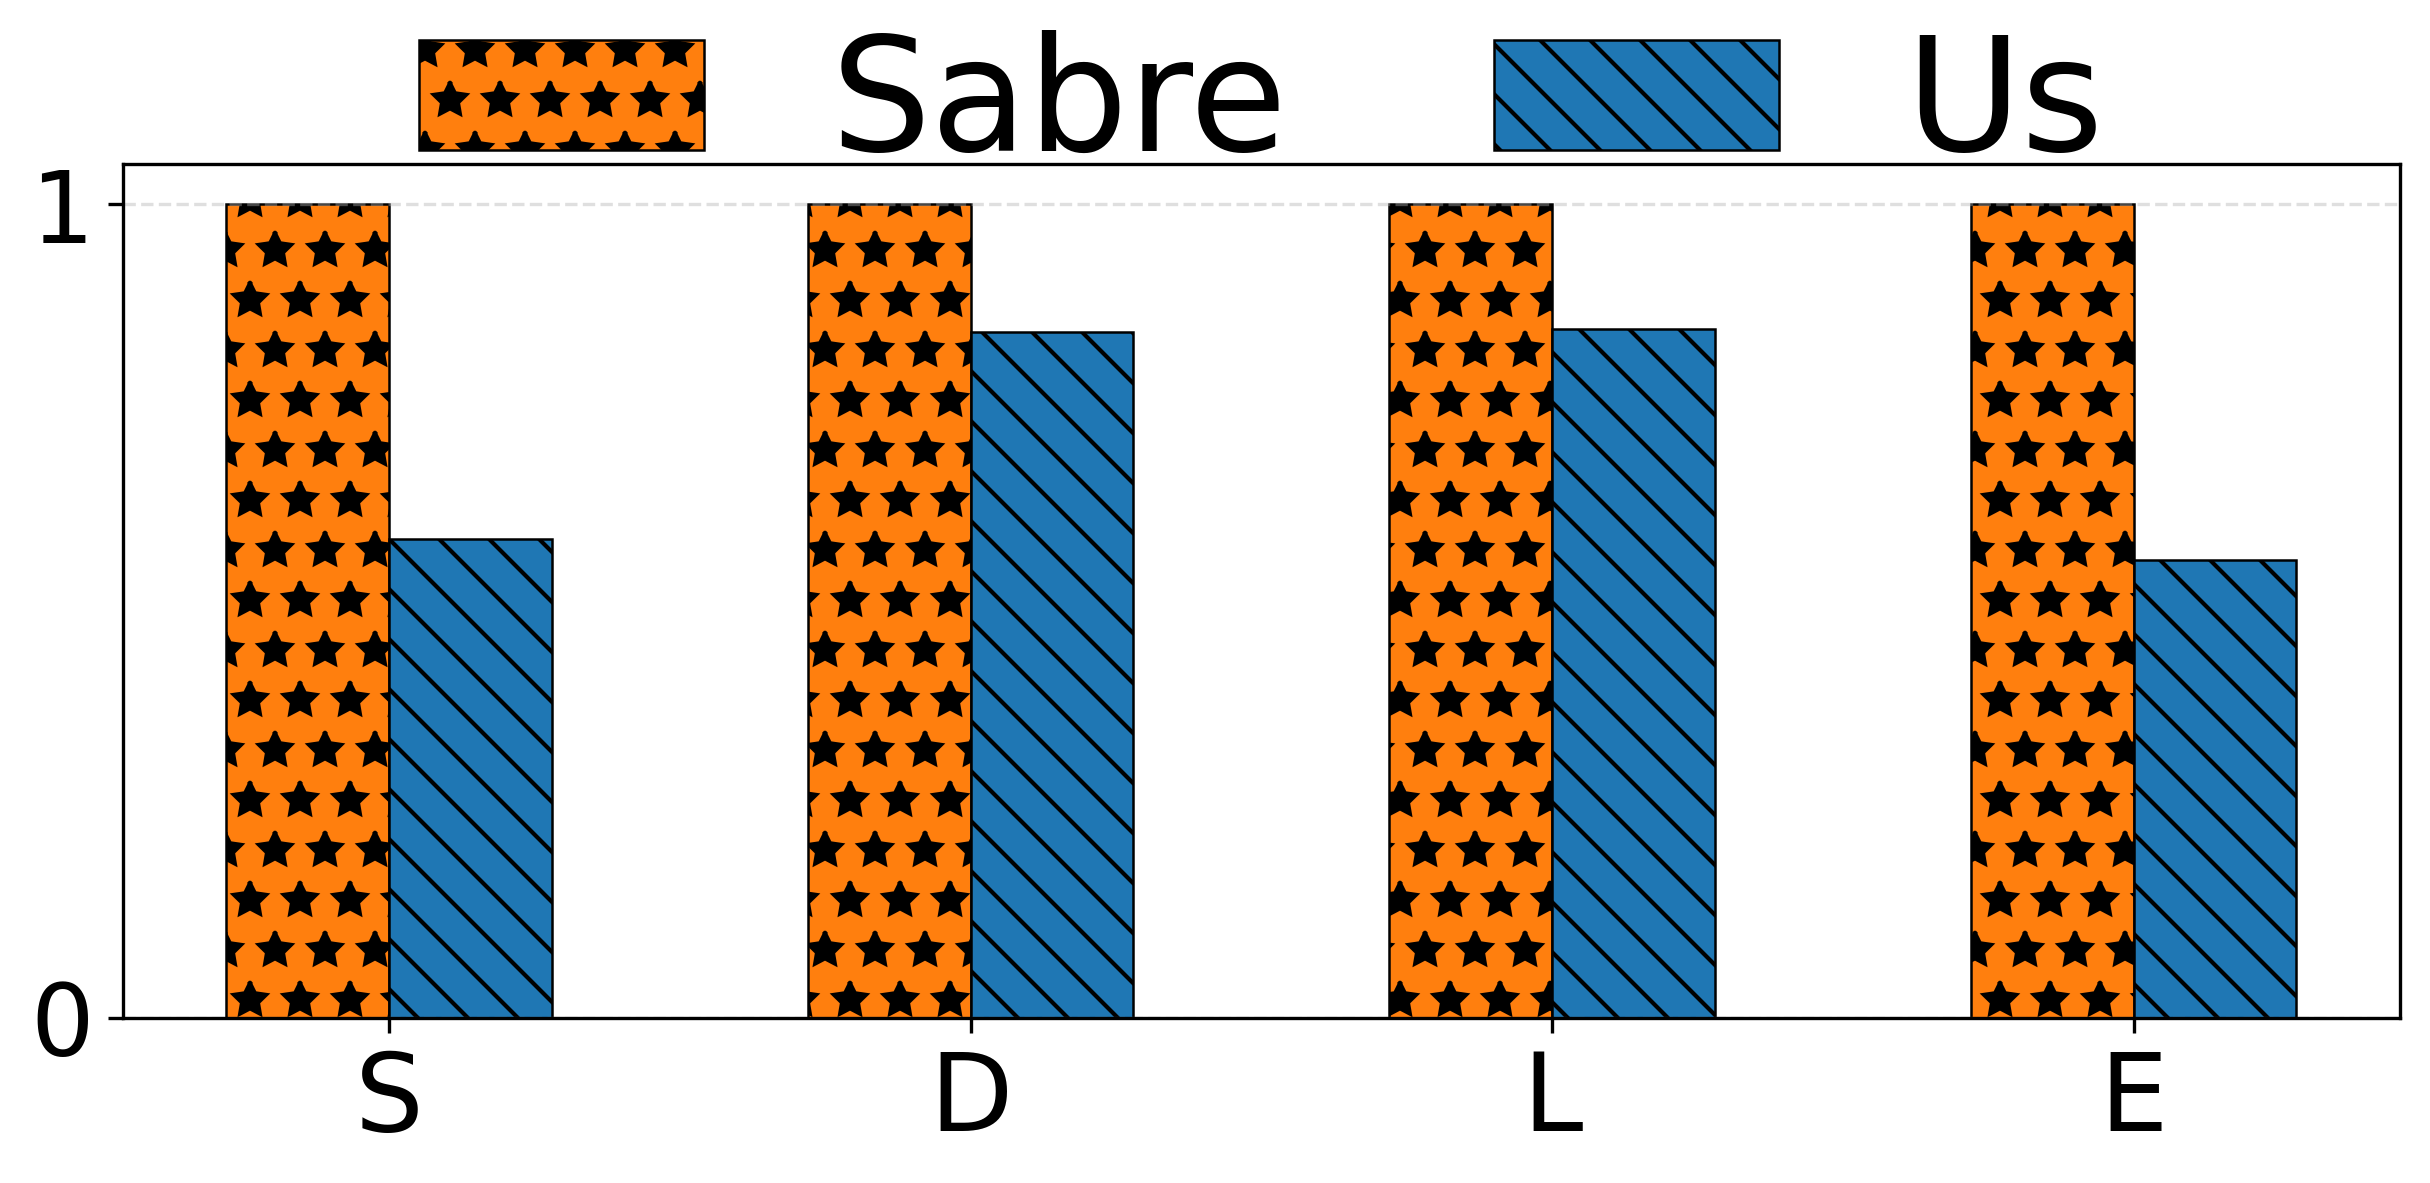

✅ Figure saved as ibm_brisbane_daynamique_121QBT_60leafdepth.pdf
  • sabre on swaps: improvement: 41.13%
  • sabre on depth: improvement: 15.70%
  • sabre on latency: improvement: 15.34%
  • sabre on error: improvement: 43.66%


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from io import StringIO

# --- Parameters ---
title = "121 Qubits — Leaf Depth = 60"
normalize = True  # set to False for raw values

# --- Input Data (CSV-style inline) ---
output_path = "ibm_brisbane_daynamique_121QBT_60leafdepth.pdf"
data = """metric,ours,sabre
swaps,4368.000000,7419.600000
depth,37547.300000,44542.600000
latency,2200058.400000,2598734.000000
error,31.443116,55.808923
"""

# output_path = "ibm_brisbane_dynamique_81QBT_5w_5i.pdf"
# data = """metric,sabre,ours
# swaps,2380,410.3333333
# depth,813.3333333,328.6666667
# latency,50280,20269.33333
# error,1.769245492,0.511063403
# """

df = pd.read_csv(StringIO(data))

methods = ['sabre', 'ours']
display_names = {'sabre': 'Sabre', 'ours': 'Us'}
metrics = df['metric'].tolist()
metric_names = ['S', 'D', 'L', 'E']

# --- Extract metric values ---
values = {m: [df.loc[df['metric'] == m, meth].values[0] for meth in methods] for m in metrics}

# --- Normalize (optional) ---
if normalize:
    for m in metrics:
        baseline = np.max(values[m])
        values[m] = [v / baseline if baseline > 0 else v for v in values[m]]
    ylabel = "Normalized Metric Value"
else:
    ylabel = "Metric Value (↓ better)"

plt.rcParams.update({
        "font.size": 20,              # base font size
        "axes.titlesize": 26,         # in case titles are used later
        "axes.labelsize": 26,         # axis labels (x/y)
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        # "legend.fontsize": 24,
        # "legend.title_fontsize": 20,
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "figure.dpi": 300 ,        # ensure crisp rendering in PDF
    })

# --- Plot ---
x = np.arange(len(metrics))
width = 0.28

colors = list(plt.cm.tab10.colors)
colors = [colors[1], colors[0]]  # Sabre (blueish), QRoQI (orange)

# 🌟 Use elegant, distinct hatches for print visibility
hatches = ['*', '\\\\']

plt.figure(figsize=(8.5, 4.5))
for i, method in enumerate(methods):
    plt.bar(
        x + i * width - width / 2,
        [values[m][i] for m in metrics],
        width=width,
        label=display_names[method],
        color=colors[i],
        edgecolor='black',
        hatch=hatches[i],
        linewidth=0.6
    )

plt.xticks(x, metric_names, fontsize=26)
# plt.ylabel('Normalized Metric Value', fontsize=22)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# --- Legend: single row with spacing ---
handles, labels = plt.gca().get_legend_handles_labels()
show_labels = ['Sabre', 'Us']
selected = [(h, l) for h, l in zip(handles, labels) if l in show_labels]
sel_handles, sel_labels = zip(*selected)

plt.legend(
    sel_handles, sel_labels,
    # frameon=True,
    fontsize=38,
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    fancybox=True,
    shadow=False,
    framealpha=0,
    borderpad=0,
    columnspacing=1.3,
    handlelength=1.8
)

plt.yticks([0, 1])
plt.tight_layout()
# plt.subplots_adjust(top=0.8)

# --- Save as high-quality PDF ---
plt.savefig(output_path, format='pdf', bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

print(f"✅ Figure saved as {output_path}")


improvements = {}
for m in metrics:
    qroq = df.loc[df['metric'] == m, 'ours'].values[0]
    if pd.isna(qroq):
        continue

    rel_impr_values = []
    for meth in methods:
        if meth == 'ours':
            continue
        val = df.loc[df['metric'] == m, meth].values[0]
        if pd.isna(val):
            continue
        if qroq < val:  # only consider improvements
            rel_impr = (val - qroq) / val * 100
            rel_impr_values.append(rel_impr)
            
            print(f"  • {meth} on {m}: improvement: {rel_impr:.2f}%")

In [4]:
# print pwd
import os
os.getcwd()

'c:\\Users\\ASUS ROG\\Downloads\\Telegram Desktop'

In [65]:

backends = ["kingston", "brisbane"]
idxs = [54,81,121]

methods = ['sabre', 'cirq', 'qmap', 'pytket', 'original_qlosure', 'with_depth']


In [66]:
display_names = {
    'sabre': 'Sabre',
    'qmap': 'Qmap',
    'cirq': 'Cirq',
    'pytket': 'Pytket',
    'original_qlosure': 'Qlosure',
    'with_depth': 'Us',
    'marouane':'Marouane'
}


metrics = {
    'swaps': 'SWAPs',
    'depth': 'Depth',
    'max_time': 'Latency (μs)',
    'avg_error': 'Error',
    #'max_error': 'Error max',
}

In [67]:
for backend in backends:
    for idx in idxs:
        print(f"\n🔍 Analyzing {backend} — {idx}qpt ...")

        # --- Load and merge data for this size ---

        merge_cols = ['cycle', 'run']
        df = None

        for method in methods:
            file_path = f'results/{backend}/{idx}qpt/{method}.csv'
            try:
                temp_df = pd.read_csv(file_path)

                if df is None:
                    df = temp_df
                else:
                    # Merge on cycle and run
                    df = pd.merge(df, temp_df, on=merge_cols, how='outer')
            except FileNotFoundError:
                print(f"{file_path} not found")

        for metric in metrics.keys():
            plot(df, metric, methods, display_names=display_names,
                ylabel=metrics[metric], title=metrics[metric], backend=backend, idx=idx)




🔍 Analyzing kingston — 54qpt ...
📄 Saved PDF: figures/static/ablation/kingston/54qpt/swaps.pdf
📄 Saved PDF: figures/static/ablation/kingston/54qpt/depth.pdf
📄 Saved PDF: figures/static/ablation/kingston/54qpt/latency.pdf
📄 Saved PDF: figures/static/ablation/kingston/54qpt/error.pdf

🔍 Analyzing kingston — 81qpt ...
📄 Saved PDF: figures/static/ablation/kingston/81qpt/swaps.pdf
📄 Saved PDF: figures/static/ablation/kingston/81qpt/depth.pdf
📄 Saved PDF: figures/static/ablation/kingston/81qpt/latency.pdf
📄 Saved PDF: figures/static/ablation/kingston/81qpt/error.pdf

🔍 Analyzing kingston — 121qpt ...
📄 Saved PDF: figures/static/ablation/kingston/121qpt/swaps.pdf
📄 Saved PDF: figures/static/ablation/kingston/121qpt/depth.pdf
📄 Saved PDF: figures/static/ablation/kingston/121qpt/latency.pdf
📄 Saved PDF: figures/static/ablation/kingston/121qpt/error.pdf

🔍 Analyzing brisbane — 54qpt ...
📄 Saved PDF: figures/static/ablation/brisbane/54qpt/swaps.pdf
📄 Saved PDF: figures/static/ablation/brisbane/5

In [68]:

def compute_improvements(df, method, baselines, metrics=("swaps", "depth")):

    results = []

    for baseline in baselines:
        if method == baseline:
            continue
        row = {"method": baseline}
        for metric in metrics:
            base_col = f"{baseline}_{metric}"
            method_col = f"{method}_{metric}"

            if base_col not in df or method_col not in df:
                continue

            # Improvement = (baseline - method) / baseline
            improvement = (df[base_col] - df[method_col])*100 / df[base_col]
            deference = df[method_col] - df[base_col]
            qops = df[method_col] 
            row[f"{metric}_improvement"] = improvement.mean()
            row[f"{metric}_deference"] = deference.mean()
            row[f"{metric}_qops"] = qops.mean()

        results.append(row)
    

    return pd.DataFrame(results)



In [69]:
compute_improvements(df, method="with_depth", baselines=methods,metrics=metrics.keys())

,method,swaps_improvement,swaps_deference,swaps_qops,depth_improvement,depth_deference,depth_qops,max_time_improvement,max_time_deference,max_time_qops,avg_error_improvement,avg_error_deference,avg_error_qops
0,sabre,11.439451,-4204.355556,27869.688889,48.087439,-3341.855556,3928.7,48.446551,-1819.832222,2094.837111,10.031298,-0.772582,6.31803
1,cirq,7.318891,-2770.977778,27869.688889,32.778920,-1668.066667,3928.7,53.286379,-2188.688667,2094.837111,10.751853,-0.838206,6.31803
2,qmap,44.676734,-24085.310345,27869.688889,52.771768,-3978.000000,3928.7,60.342945,-2947.603218,2094.837111,37.641834,-3.968612,6.31803
3,pytket,27.376629,-10997.132530,27869.688889,61.255906,-5741.975904,3928.7,63.388238,-3375.562169,2094.837111,22.252695,-1.836857,6.31803
4,original_qlosure,-4.696969,419.722222,27869.688889,27.933073,-1476.533333,3928.7,28.038782,-797.622000,2094.837111,-2.243340,0.012912,6.31803


---------------------------------

-----------------

--------------------

In [70]:
# methods = ['0.0','0.1','0.2','0.3','0.4', '0.5']
# df = None

# for method in methods:
#     file_path = f'results/abalation/{backend}/{method}.csv'
#     try:
#         temp_df = pd.read_csv(file_path)

#         if df is None:
#             df = temp_df
#         else:
#             # Merge on cycle and run
#             df = pd.merge(df, temp_df, on=merge_cols, how='outer')
#     except FileNotFoundError:
#         print(f"{file_path} not found")


# display_names = {
#     '0.0': 'weight 0.0',
#     '0.1': 'weight 0.1',
#     '0.2': 'weight 0.2',
#     '0.3': 'weight 0.3',
#     '0.4': 'weight 0.4',
#     '0.5': 'weight 0.5',
# }


# for metric in metrics.keys():
#      plot(df, metric, methods, display_names=display_names,
#          ylabel=metrics[metric], title=metrics[metric])


In [71]:
#compute_improvements(df, method="0.5", baselines=methods,metrics=metrics.keys())

In [72]:
methods = [
    "distance_only",
    #"no_layer_weight",
    "no_depth",
    #"no_crit_deps",
    #"depth_priority",
    "with_errors",
    
    "default",
    #"new_default",


]
df = None

for method in methods:
    file_path = f'results/abalation/brisbane/81qpt/{method}.csv'
    try:
        temp_df = pd.read_csv(file_path)

        if df is None:
            df = temp_df
        else:
            # Merge on cycle and run
            df = pd.merge(df, temp_df, on=merge_cols, how='outer')
    except FileNotFoundError:
        print(f"{file_path} not found")


display_names = {
    'distance_only': 'a',
    'no_depth': 'b',
    #'no_layer_weight': 'No Layer Weight',
    #'no_crit_deps': 'Depth Enhanced',
    #'depth_priority': 'Depth Priority',
    'default': 'd',
    'new_default': 'QroQi+',
    'with_errors': 'c'
}


# for metric in metrics.keys()
#      plot(df, metric, methods, display_names=display_names,
#          ylabel=metrics[metric], title=metrics[metric])


In [73]:

def calc_improvement(df, methods, metrics):
    results = []

    baseline = "distance_only"

    for method in methods:
        if method == baseline:
            continue
        # use display name if available
        row = {"method": display_names.get(method, method)}
        for metric in metrics:
            base_col = f"{baseline}_{metric}"
            method_col = f"{method}_{metric}"

            if base_col not in df or method_col not in df:
                continue

            # Improvement = (baseline - method) / baseline
            improvement = (df[base_col] - df[method_col]) * 100 / df[base_col]

            row[f"{metric}_improvement"] = improvement.mean()

        results.append(row)

    return pd.DataFrame(results)


calc_improvement(df, methods=methods, metrics=metrics.keys())

,method,swaps_improvement,depth_improvement,max_time_improvement,avg_error_improvement
0,b,14.429506,35.035060,34.592511,9.333369
1,c,32.543603,36.885761,38.480414,25.193176
2,d,37.208178,48.284320,50.274712,29.399982


In [75]:
backend = "brisbane"
idx = 81
for metric in metrics.keys():
    plot(df, metric, methods, display_names=display_names,
         ylabel=metrics[metric], title=metrics[metric], backend=backend, idx=idx)


📄 Saved PDF: figures/static/ablation/brisbane/81qpt/swaps.pdf
📄 Saved PDF: figures/static/ablation/brisbane/81qpt/depth.pdf
📄 Saved PDF: figures/static/ablation/brisbane/81qpt/latency.pdf
📄 Saved PDF: figures/static/ablation/brisbane/81qpt/error.pdf


----------------------

In [13]:
def analyze_results(backend, benchmark):
    import pandas as pd

    methods = ['cirq', 'sabre', 'pytket', 'qmap', 'qlosure', 'qroqi']

    dfs = []
    for method in methods:
        path = f'results/{backend}/{benchmark}/{method}.csv'
        try:
            df = pd.read_csv(path)
            df = df.rename(columns={col: f'{method}_{col}' for col in ['swaps', 'depth', 'latency', 'error']})
            df = df[['filename', f'{method}_swaps', f'{method}_depth', f'{method}_latency', f'{method}_error', 'num_qubits']]
            dfs.append(df)
        except FileNotFoundError:
            print(f'{path} not found')
            continue

    if not dfs:
        print("No data found")
        return

    merged = dfs[0]
    for df in dfs[1:]:
        # Drop 'num_qubits' to avoid duplicates
        if 'num_qubits' in df.columns:
            df = df.drop(columns=['num_qubits'])
        merged = pd.merge(merged, df, on='filename', how='outer')
    

    # Select columns
    cols = ['filename', 'num_qubits']
    for method in methods:
        for metric in ['swaps', 'depth', 'latency', 'error']:
            cols.append(f'{method}_{metric}')
    merged = merged[cols]

    # Add min method columns
    for metric in ['swaps', 'depth', 'latency', 'error']:
        metric_cols = [f'{method}_{metric}' for method in methods]
        merged[f'{metric}_min_method'] = merged[metric_cols].idxmin(axis=1).str.replace(f'_{metric}', '')

    # Style the table: bold the minimum values for each metric per row
    def highlight_min(data):
        styles = pd.DataFrame('', index=data.index, columns=data.columns)
        for idx in data.index:
            row = data.loc[idx]
            for metric in ['swaps', 'depth', 'latency', 'error']:
                metric_cols = [f'{method}_{metric}' for method in methods]
                min_val = row[metric_cols].min()
                for col in metric_cols:
                    if row[col] == min_val:
                        styles.loc[idx, col] = 'font-weight: bold; background-color: lightgreen'
        return styles

    styled = merged.style.apply(highlight_min, axis=None)

    # Display the table
    display(styled)

    # Print summary of which method gets minimum in each metric overall
    print("\n=== Summary of Minimum Methods per Metric ===")
    for metric in ['swaps', 'depth', 'latency', 'error']:
        counts = merged[f'{metric}_min_method'].value_counts()
        print(f"{metric.upper()}:")
        for method, count in counts.items():
            print(f"  {method}: {count} circuits")
            
    # save it in csv
    merged.to_csv(f'results/{backend}/{benchmark}/merged_results.csv', index=False)





In [14]:
# backend = "ibm_brisbane"
# benchmark = "qasmbench-medium"
# analyze_results(backend, benchmark)

In [15]:
# backend = "ibm_kingston"
# benchmark = "qasmbench-medium"
# analyze_results(backend, benchmark)

In [16]:
# backend = "ibm_kingston"
# benchmark = "qasmbench-large"
# analyze_results(backend, benchmark)

In [17]:
# import os
# import csv
# import argparse
# from src.utils.isl_data_loader import json_file_to_isl, qasm_file_to_access
# from src.mapping.routing import Qlosure
# from qpu.src.load_backend import load_backend

# data = qasm_file_to_access("benchmarks/polyhedral/qasmbench-large/adder_n64__78CYC.json")
# topology = load_backend("ibm_kingston")


# error_matrix = Qlosure(topology, data).error_matrix

In [18]:
# data = qasm_file_to_access("benchmarks/polyhedral/qasmbench-medium/wstate_n27__55CYC.json")

In [19]:
# Qlosure(topology, data,error_matrix=error_matrix).run(heuristic_method="qroqi",ablation_variant="with_error",look_ahead_param=3,w_depth=0.1, verbose=1)

In [20]:
# Qlosure(topology, data,error_matrix=error_matrix).run(heuristic_method="qlosure",look_ahead_param=4, verbose=1)

In [21]:
# import pandas as pd
# import io
# import numpy as np

# path = "results/ibm_brisbane/merged.csv"
# # 2. Setup Tools and Metrics
# TOOLS = ['Cirq', 'Sabre', 'Pytket', 'QMap', 'QLosure']
# METRICS = ['Swaps', 'Depth', 'Latency', 'Error']
# QROQI_PREFIX = 'QROQI'

# # 3. Read and Clean Data
# df = pd.read_csv(path)

# # Replace missing value markers ('-') with NaN for proper calculation
# cols_to_convert = [c for c in df.columns if c not in ['Circuit', 'Qubits']]
# # replace '-' with NaN then convert columns to numeric (coerce invalid -> NaN)
# df[cols_to_convert] = df[cols_to_convert].replace('-', np.nan).apply(pd.to_numeric, errors='coerce')

# # 4. Calculate Average Improvement
# # Improvement is defined as (1 - (QROQI_Metric / Tool_Metric)) * 100
# improvement_results = {}

# for tool in TOOLS:
#     improvement_results[tool] = {}
#     for metric in METRICS:
#         # Define the column names for the current tool and QROQI
#         tool_col = f'{tool}_{metric}'
#         qroqi_col = f'{QROQI_PREFIX}_{metric}'

#         # Calculate improvement for each circuit
#         improvement = (1 - (df[qroqi_col] / df[tool_col])) * 100

#         # Calculate the average, ignoring NaN values (circuits where data was missing)
#         avg_improvement = improvement.mean()

#         improvement_results[tool][metric] = avg_improvement

# # Convert results to a final DataFrame for clean display
# results_df = pd.DataFrame(improvement_results).T

# # 5. Print Results
# print("## 📊 Average Improvement of QROQI Over Other Tools (in %)\n")
# print("> Improvement is calculated as the average percentage reduction in the metric (since lower is better).\n")
# print(results_df.to_markdown(floatfmt=".2f"))


In [22]:
# backend = "ibm_brisbane"
# benchmark = "qasmbench-large"
# analyze_results(backend, benchmark)


In [23]:
# import pandas as pd
# import os

# def load_backend_results(backend, benchmark, methods):
#     dfs = []
#     for method in methods:
#         path = f'results/{backend}/{benchmark}/{method}.csv'
#         if not os.path.exists(path):
#             print(f"{path} not found")
#             continue
#         df = pd.read_csv(path)
#         df = df.rename(columns={col: f'{backend}_{method}_{col}' for col in ['swaps', 'depth', 'latency', 'error']})
#         dfs.append(df[['filename',
#                        f'{backend}_{method}_swaps',
#                        f'{backend}_{method}_depth',
#                        f'{backend}_{method}_latency',
#                        f'{backend}_{method}_error',
#                        'num_qubits']])
    
#     if not dfs:
#         return None
#     merged = dfs[0]
#     for df in dfs[1:]:
#         if 'num_qubits' in df.columns:
#             df = df.drop(columns=['num_qubits'])
#         merged = pd.merge(merged, df, on='filename', how='outer')
#     return merged

# def qroqi_score_across_backends(backend1, backend2, benchmark):
#     methods = ['cirq', 'sabre', 'pytket', 'qmap', 'qlosure', 'qroqi']
#     metrics = ['swaps', 'depth', 'latency', 'error']
    
#     df1 = load_backend_results(backend1, benchmark, methods)
#     df2 = load_backend_results(backend2, benchmark, methods)
#     if df1 is None or df2 is None:
#         print(f"⚠️ Missing data for {benchmark}")
#         return None
    
#     combined = pd.merge(df1, df2, on='filename', how='inner')
    
#     results = []
#     for _, row in combined.iterrows():
#         qroqi_min_count = 0
#         total_metrics = len(metrics) * 2  # 8 total
#         for backend in [backend1, backend2]:
#             for metric in metrics:
#                 metric_cols = [f"{backend}_{m}_{metric}" for m in methods]
#                 vals = row[metric_cols]
#                 min_val = vals.min()
#                 min_methods = vals[vals == min_val].index.tolist()
#                 if any("qroqi" in col for col in min_methods):
#                     qroqi_min_count += 1
#         results.append({
#             "filename": row["filename"],
#             "num_qubits": row.get("num_qubits", None),
#             "qroqi_min_count": qroqi_min_count,
#             "total_metrics": total_metrics
#         })
    
#     df_results = pd.DataFrame(results)
#     df_results["qroqi_ratio"] = df_results["qroqi_min_count"] / df_results["total_metrics"]
    
#     print(f"=== Benchmark: {benchmark} ===")
#     print(f"Average QROQI score: {df_results['qroqi_ratio'].mean():.2f}")
#     print(f"Number of circuits where QROQI wins all 8 metrics: {(df_results['qroqi_min_count'] == 8).sum()}")
#     print()
    
#     # Sort by best performance (most wins)
#     df_sorted = df_results.sort_values(by="qroqi_min_count", ascending=False)
#     return df_sorted



In [ ]:
# # Example for both benchmarks
# backend1 = "ibm_kingston"
# backend2 = "ibm_brisbane"
# benchmarks = ["qasmbench-medium", "qasmbench-large"]

# all_sorted = []
# for bench in benchmarks:
#     df_sorted = qroqi_score_across_backends(backend1, backend2, bench)
#     if df_sorted is not None:
#         df_sorted["benchmark"] = bench
#         all_sorted.append(df_sorted)

# # Combine both benchmarks
# if all_sorted:
#     combined_all = pd.concat(all_sorted, ignore_index=True)
#     print("=== Combined Results (sorted) ===")
#     print(combined_all.sort_values(by="qroqi_min_count", ascending=False)[
#         ["benchmark", "filename", "qroqi_min_count", "total_metrics", "qroqi_ratio"]
#     ])



NameError: name 'qroqi_score_across_backends' is not defined

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

backend = "ibm_kingston"
sizes = [54, 81, 121]
dfs = {}

for n in sizes:
    path = f"results/{backend}/queko-bss-{n}qbt/qroqi_exec_time.csv"
    df = pd.read_csv(path)
    df['cycle'] = df['filename'].str.extract(r'_(\d+)CYC_').astype(int)
    df['run'] = df['filename'].str.extract(r'_QSE_(\d+)').astype(int)
    df.rename(columns={'exec_time': f'exec_time_{n}q'}, inplace=True)
    dfs[n] = df[['cycle', f'exec_time_{n}q']]

# Merge by cycle
df_merged = dfs[54].copy()
for n in sizes[1:]:
    df_merged = pd.merge(df_merged, dfs[n], on='cycle', how='outer')


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

def plot_exec_time_across_sizes(
    df, methods, display_names, save_path="execution_time.pdf", use_log_scale=False
):
    """
    Publication-style plot of average execution time vs. cycle for multiple methods.
    - One marker per cycle (mean only) with ±std shading.
    - Matches the QROQI publication figure style.
    """

    # ---- Publication style ----
    plt.rcParams.update({
        "font.size": 20,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "legend.title_fontsize": 20,
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "figure.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    colors = list(plt.cm.tab10.colors)
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X']
    handles = []

    xs = sorted(df['cycle'].unique())

    for i, method in enumerate(methods):
        label = display_names.get(method, method)
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]

        col_name = f'exec_time_{method}'
        ys_lists = []
        for x in xs:
            y_vals = df[df['cycle'] == x][col_name].dropna().tolist()
            ys_lists.append(y_vals)

        means = np.array([np.mean(y) if len(y) > 0 else np.nan for y in ys_lists])
        stds  = np.array([np.std(y) if len(y) > 0 else np.nan for y in ys_lists])

        # Plot mean line + marker per cycle
        ax.plot(xs, means, color=color, marker=marker, label=label)
        ax.fill_between(xs, means - stds, means + stds, color=color, alpha=0.15)

        # Legend handle
        handles.append(Line2D([0], [0], color=color, marker=marker, lw=2.5,
                              markersize=10, label=label))

    # ---- Axis formatting ----
    ax.set_xlabel("Initial depth")
    ax.set_ylabel("Average time (s)")
    if use_log_scale:
        ax.set_yscale("log")

    ax.grid(True, alpha=0.3)
    ax.legend(handles=handles, loc="best", frameon=False)
    ax.set_ylim(bottom=0)

    plt.tight_layout()

    # ---- Save PDF ----
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"📄 Saved PDF: {save_path}")

    plt.show()
    plt.close(fig)


📄 Saved PDF: paper-images/ibm_kingston/execution_time.pdf


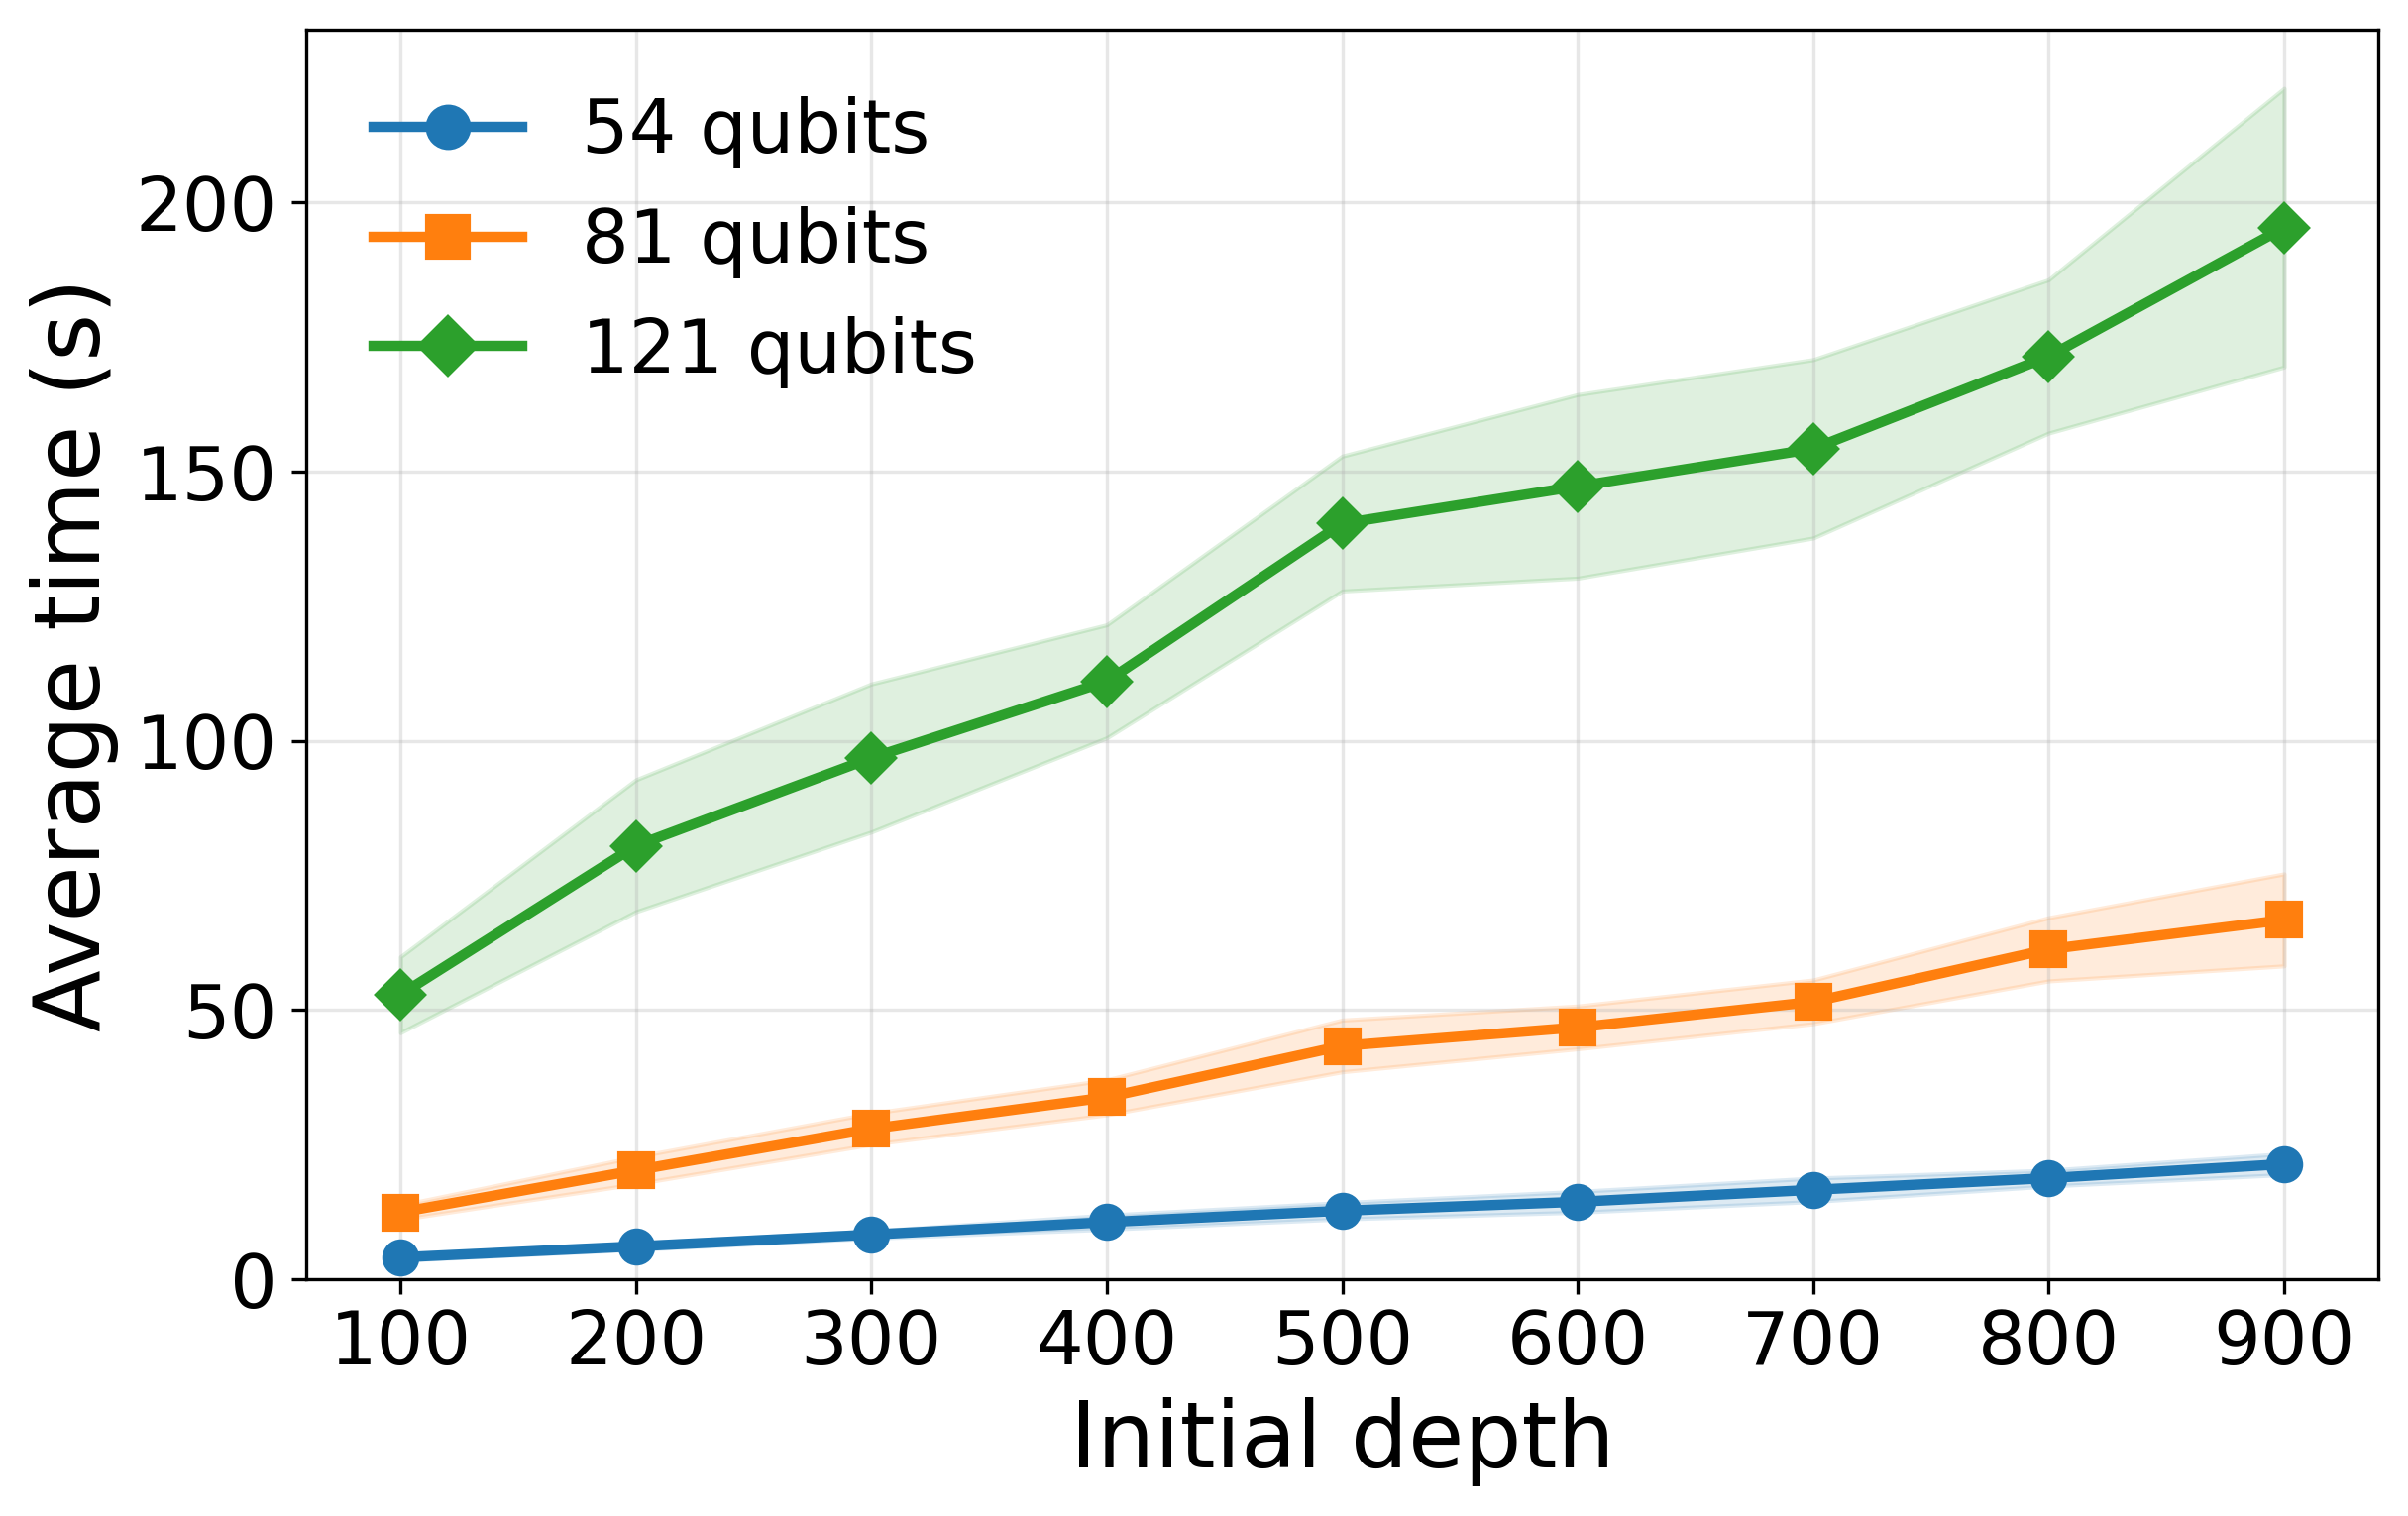

In [37]:
methods = ['54q', '81q', '121q']
display_names = {
    '54q': '54 qubits',
    '81q': '81 qubits',
    '121q': '121 qubits'
}


plot_exec_time_across_sizes(
    df=df_merged,
    methods=methods,
    display_names=display_names,
    save_path=f"paper-images/{backend}/execution_time.pdf"
)


In [26]:
backend = "ibm_kingston"
bench = 121
methods = ['sabre','cirq','qmap','pytket','qlosure', 'qroqi']

for method in methods:
    df = pd.read_csv(f'results/{backend}/queko-bss-{bench}qbt/{method}_exec_time.csv')
    df['cycle'] = df['filename'].str.extract(r'_(\d+)CYC_').astype(int)
    small = df[(df['cycle'] >=100) & (df['cycle'] <=300)]['exec_time'].mean()
    medium = df[(df['cycle'] >300) & (df['cycle'] <=600)]['exec_time'].mean()
    large = df[(df['cycle'] >600) & (df['cycle'] <=900)]['exec_time'].mean()
    print(f"{method}: small: {small:.2f}s, medium: {medium:.2f}s, large: {large:.2f}s")


sabre: small: 0.83s, medium: 1.92s, large: 3.06s
cirq: small: nans, medium: nans, large: nans
qmap: small: 115.86s, medium: 195.80s, large: 204.95s
pytket: small: nans, medium: 174.77s, large: 359.98s
qlosure: small: 102.81s, medium: 175.11s, large: 218.90s
qroqi: small: 76.74s, medium: 132.90s, large: 173.66s


---------------